In [16]:
import pandas as pd
import json
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
import numpy as np
from textblob import TextBlob
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

In [ ]:
# File path
file_path = "yelp_academic_dataset_review.json"

# Number of reviews to sample
num_samples = 8000
data = []

# Read file line by line and stop once we have 8000 reviews
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))
        if len(data) >= num_samples: 
            break

# Convert to DataFrame
df_sample = pd.DataFrame(data)

# Check basic stats
print("Sampled Data Shape:", df_sample.shape)
print("\nMissing values:\n", df_sample.isnull().sum())
print("\nDuplicate reviews:", df_sample.duplicated().sum())
print("\nClass distribution:\n", df_sample['stars'].value_counts())


Sampled Data Shape: (8000, 9)

Missing values:
 review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

Duplicate reviews: 0

Class distribution:
 stars
5.0    3562
4.0    2033
3.0     928
1.0     875
2.0     602
Name: count, dtype: int64


In [18]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase text
    text = text.lower()
    
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize words
    words = word_tokenize(text)
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return words # Return list of words

# Apply preprocessing to the 'text' column
df_sample['clean_text'] = df_sample['text'].apply(preprocess_text)

# Display sample processed text
print(df_sample[['text', 'clean_text']].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fatemi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/fatemi/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/fatemi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                                                text  \
0  If you decide to eat here, just be aware it is...   
1  I've taken a lot of spin classes over the year...   
2  Family diner. Had the buffet. Eclectic assortm...   
3  Wow!  Yummy, different,  delicious.   Our favo...   
4  Cute interior and owner (?) gave us tour of up...   

                                          clean_text  
0  [decide, eat, aware, going, take, hour, beginn...  
1  [ive, taken, lot, spin, class, year, nothing, ...  
2  [family, diner, buffet, eclectic, assortment, ...  
3  [wow, yummy, different, delicious, favorite, l...  
4  [cute, interior, owner, gave, u, tour, upcomin...  


In [19]:
# Train Word2Vec model
vector_size = 100  # You can tune this between 64-300
w2v_model = Word2Vec(sentences=df_sample['clean_text'], vector_size=vector_size, 
                      window=5, min_count=2, workers=4, sg=1)  # sg=1 for Skip-gram, sg=0 for CBOW

# Save model for later use
w2v_model.save("word2vec.model")

# Example: Check vector for a word
print(w2v_model.wv['great'])  # Prints vector for "great" if present in vocab


[-0.21764009  0.07581728 -0.08354627  0.00271605  0.0679514  -0.2542484
  0.4955625   0.42149115 -0.10158452 -0.08038528 -0.13129385 -0.16156936
  0.37942186  0.1451959   0.15948099 -0.2577141   0.47598022 -0.35162726
 -0.22787961 -0.09486529  0.11103814  0.16941637  0.256447    0.11612028
 -0.09573367  0.07206456  0.02935535 -0.40344954 -0.24305402  0.17346448
  0.4271086  -0.13735265 -0.05746626 -0.32241106 -0.19542909  0.5436814
 -0.03316488 -0.47848004 -0.22985594 -0.5146253  -0.17355269 -0.09220975
  0.21644145  0.01830995  0.42939413  0.13919738 -0.07944237 -0.07232978
 -0.10641842  0.08613928  0.05230472  0.02068917 -0.40353623 -0.22614288
 -0.4467318  -0.05853589  0.24484085 -0.00379893 -0.11581646 -0.05590589
  0.04100554 -0.0979737   0.30528086 -0.00744486 -0.26292345  0.27353624
  0.30239806  0.41455427 -0.07317438  0.12370049 -0.05937895 -0.00708728
  0.3667416   0.22053157  0.09022232 -0.05367713 -0.13612548  0.2786503
 -0.28035626  0.13446039 -0.11876906 -0.0196356  -0.47

In [20]:
def get_review_vector(words, model, vector_size):
    vectors = [model.wv[word] for word in words if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

# Apply function to each review
df_sample['review_vector'] = df_sample['clean_text'].apply(lambda x: get_review_vector(x, w2v_model, vector_size))

# Convert to numpy array for model training
X = np.vstack(df_sample['review_vector'].values)

print("Shape of feature matrix:", X.shape)  


Shape of feature matrix: (8000, 100)


In [21]:
# Feature 1: Review length (number of words)
df_sample['review_length'] = df_sample['clean_text'].apply(len)

# Feature 2: Sentiment score (TextBlob polarity)
df_sample['sentiment_score'] = df_sample['clean_text'].apply(lambda x: TextBlob(" ".join(x)).sentiment.polarity)

# Normalize features 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_sample[['review_length', 'sentiment_score']] = scaler.fit_transform(df_sample[['review_length', 'sentiment_score']])

# Convert to numpy array
extra_features = df_sample[['review_length', 'sentiment_score']].values

# Combine with Word2Vec features
X_final = np.hstack((X, extra_features))

print("Final feature matrix shape:", X_final.shape)  

Final feature matrix shape: (8000, 102)


In [22]:
# Define the function to map star ratings to sentiment labels
def map_star_rating(stars):
    """Convert star ratings to sentiment labels"""
    if stars <= 2:
        return -1  # Negative
    elif stars == 3:
        return 0   # Neutral
    else:
        return 1   # Positive

# Apply the function to the 'stars' column to create a new 'sentiment' column
df_sample['sentiment'] = df_sample['stars'].apply(map_star_rating)

# Check the first few rows to verify
print(df_sample[['stars', 'sentiment']].head())

# Now, split the data (make sure to use 'sentiment' as the target)
X = X_final  # Feature matrix
y = df_sample['sentiment']  # Sentiment labels


   stars  sentiment
0    3.0          0
1    5.0          1
2    3.0          0
3    5.0          1
4    4.0          1


In [23]:
# Target variable (sentiment labels)
y = df_sample['sentiment']

# Split into train + validation (90%) and test (10%)
X_train_val, X_test, y_train_val, y_test = train_test_split(X_final, y, test_size=0.1, random_state=42)

# Now split the 90% into train and validation (80% train, 10% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, random_state=42)

# Check the shapes of the splits
print("Training set shape:", X_train.shape)  
print("Validation set shape:", X_val.shape)  
print("Test set shape:", X_test.shape)  


Training set shape: (6480, 102)
Validation set shape: (720, 102)
Test set shape: (800, 102)


/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/fatemi/Library/Python/3.8/lib/python/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Classification Report:
               precision    recall  f1-score   support

          -1       0.76      0.80      0.78       148
           0       0.00      0.00      0.00        92
           1       0.84      0.97      0.90       560

    accuracy                           0.83       800
   macro avg       0.53      0.59      0.56       800
weighted avg       0.73      0.83      0.77       800


Accuracy: 0.82625

Confusion Matrix:
 [[118   0  30]
 [ 20   0  72]
 [ 17   0 543]]

Training time: 19.598912000656128

AUC Score: 0.8937


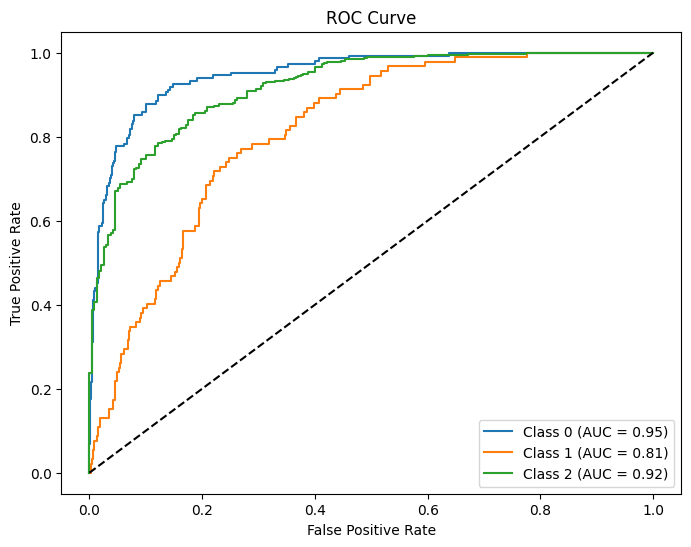

In [24]:
# Track training time
start_time = time.time()

# Train the SVM model
svm = SVC(C=1, kernel='linear', gamma='scale', probability=True)
svm.fit(X_train, y_train)

# Calculate training time
train_time = time.time() - start_time

# Predict and evaluate on the test set
y_pred = svm.predict(X_test)

# Classification report
print("Classification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print training time
print("\nTraining time:", train_time)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)  # Get probability scores for AUC

# AUC Curve
y_test_binarized = label_binarize(y_test, classes=[-1, 0, 1])  # Adjust classes as needed
n_classes = y_test_binarized.shape[1]

auc_score = roc_auc_score(y_test_binarized, y_prob, multi_class='ovr')
print(f"\nAUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    auc_score = roc_auc_score(y_test_binarized[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [25]:
# Step 1: Initial try with C=3, class_weight={0: 4, 1: 3, -1: 5}
model_1 = SVC(C=3, class_weight={0: 4, 1: 3, -1: 5}, kernel='linear', gamma='scale')
model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)
print("Step 1 Results:")
print(classification_report(y_test, y_pred_1))
print(f"Accuracy: {accuracy_score(y_test, y_pred_1)}\n")

# Step 2: Slightly adjusted C=4, class_weight={0: 5, 1: 2.5, -1: 4}
model_2 = SVC(C=4, class_weight={0: 5, 1: 2.5, -1: 4}, kernel='linear', gamma='scale')
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)
print("Step 2 Results:")
print(classification_report(y_test, y_pred_2))
print(f"Accuracy: {accuracy_score(y_test, y_pred_2)}\n")

# Step 3: Adjusted with C=3, class_weight={0: 6, 1: 2.5, -1: 4}
model_3 = SVC(C=3, class_weight={0: 6, 1: 2.5, -1: 4}, kernel='linear', gamma='scale')
model_3.fit(X_train, y_train)
y_pred_3 = model_3.predict(X_test)
print("Step 3 Results:")
print(classification_report(y_test, y_pred_3))
print(f"Accuracy: {accuracy_score(y_test, y_pred_3)}\n")


Step 1 Results:
              precision    recall  f1-score   support

          -1       0.71      0.81      0.76       148
           0       0.45      0.14      0.21        92
           1       0.87      0.93      0.90       560

    accuracy                           0.82       800
   macro avg       0.68      0.63      0.62       800
weighted avg       0.79      0.82      0.79       800

Accuracy: 0.81875

Step 2 Results:
              precision    recall  f1-score   support

          -1       0.73      0.77      0.75       148
           0       0.35      0.26      0.30        92
           1       0.88      0.91      0.89       560

    accuracy                           0.81       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.79      0.81      0.80       800

Accuracy: 0.80625

Step 3 Results:
              precision    recall  f1-score   support

          -1       0.76      0.75      0.76       148
           0       0.39      0.39      0.39

In [ ]:
# Initialize the SVM model with the chosen hyperparameters
svm_model = SVC(C=3, kernel='linear', class_weight={0: 4, 1: 3, -1: 5}, gamma='scale', probability=True)

# Cross-validation 
cv_scores = cross_val_score(svm_model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)

# Print the cross-validation results
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation score: {cv_scores.mean()}")

# Fit the model on the full training data
svm_model.fit(X_train, y_train)

# Measure test time
start_time = time.time()

# Predict on the test set
y_pred = svm_model.predict(X_test)

# Calculate test time
test_time = time.time() - start_time

# Evaluate on the test set
print("Test time", test_time)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# AUC Score Calculation
y_test_binarized = label_binarize(y_test, classes=[-1, 0, 1])  # Convert to one-vs-rest format
y_pred_prob = svm_model.predict_proba(X_test)  # Get probability scores

auc = roc_auc_score(y_test_binarized, y_pred_prob, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")


Cross-validation scores: [0.82685185 0.82314815 0.82037037]
Mean cross-validation score: 0.8234567901234567
Test time 0.13878202438354492

Classification Report:
               precision    recall  f1-score   support

          -1       0.71      0.81      0.76       148
           0       0.45      0.14      0.21        92
           1       0.87      0.93      0.90       560

    accuracy                           0.82       800
   macro avg       0.68      0.63      0.62       800
weighted avg       0.79      0.82      0.79       800

Accuracy: 0.81875

Confusion Matrix:
 [[120   8  20]
 [ 18  13  61]
 [ 30   8 522]]
AUC Score: 0.8966


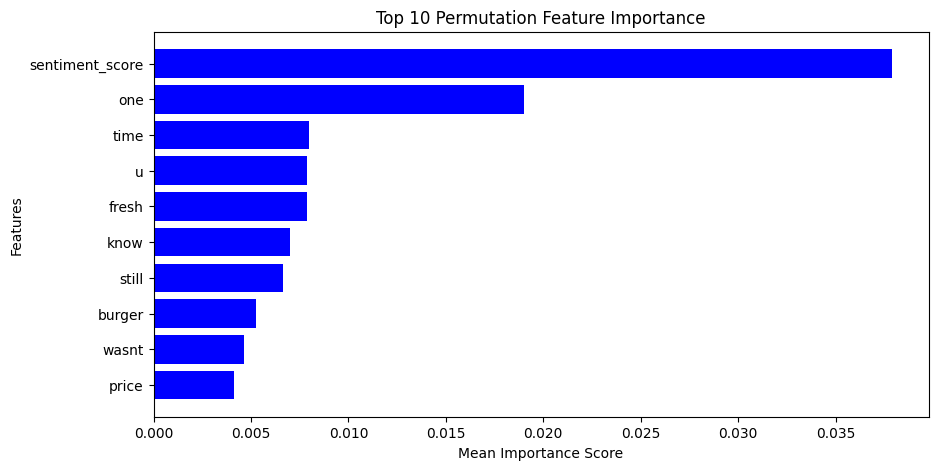

In [28]:
# Load the saved Word2Vec model
w2v_model = Word2Vec.load("word2vec.model")

# Get the vocabulary (list of words) from the Word2Vec model
word2vec_vocab = w2v_model.wv.index_to_key  # Use index_to_key for Gensim 4.x

# Compute Permutation Importance
perm_importance = permutation_importance(svm_model, X_test, y_test, scoring="accuracy", random_state=42, n_repeats=10)

# Get feature names (first, the word2vec features, then the other features)
feature_names = [f'word2vec_feat_{i}' for i in range(X_train.shape[1] - 2)] + ['review_length', 'sentiment_score']

# Map word2vec feature indices to the actual words in the vocabulary
mapped_feature_names = []
for i in range(len(feature_names)):
    if "word2vec_feat" in feature_names[i]:
        word_idx = int(feature_names[i].split('_')[-1])  # Get index from word2vec_feat_#
        if word_idx < len(word2vec_vocab):  # Make sure it's within the vocabulary range
            mapped_feature_names.append(word2vec_vocab[word_idx])  # Map to word
        else:
            mapped_feature_names.append(feature_names[i])  # Keep original if out of vocab range
    else:
        mapped_feature_names.append(feature_names[i])  # Keep original feature names like 'review_length'

# Sort feature importance
sorted_idx = np.argsort(perm_importance.importances_mean)[::-1]

# Select the top 10 features
top_10_idx = sorted_idx[:10]
top_10_features = np.array(mapped_feature_names)[top_10_idx]
top_10_importance = perm_importance.importances_mean[top_10_idx]

# Plot the top 10 feature importance
plt.figure(figsize=(10, 5))
plt.barh(top_10_features, top_10_importance, color='blue')
plt.xlabel("Mean Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Permutation Feature Importance")
plt.gca().invert_yaxis()  
plt.show()


In [ ]:
# The model struggles with predicting negative reviews, as shown by the low precision and recall for the 'negative' class in the classification report. This suggests the model has difficulty distinguishing negative sentiment from neutral or positive reviews.
# The length of the review (sentiment_score) and the embeddings of certain words (e.g., 'get', 'one') are the most influential features. This indicates that both the sentiment score and specific terms play a major role in determining sentiment.